# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install gensim transformers torch sentence-transformers datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.3.3
Setup complete!


## Load Dataset (Same as Part 1)

In [2]:
import pandas as pd
from pathlib import Path

# Load the dataset
possible_paths = [
    Path('20_newsgroups_train (1).csv'),
    Path('20_newsgroups_train.csv'),
    Path('/mnt/data/20_newsgroups_train (1).csv'),
    Path('/mnt/data/20_newsgroups_train.csv')
]

for csv_path in possible_paths:
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        break
else:
    raise FileNotFoundError('Could not find the 20 Newsgroups CSV file.')

# NOTE: Part 1 categories were not provided with this notebook,
# so I selected 3 clear, high-signal categories for a complete solution.
my_categories = ["comp.graphics", "sci.space", "rec.sport.hockey"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['comp.graphics', 'sci.space', 'rec.sport.hockey']
Filtered dataset size: 1777


In [3]:
# Preprocessing function (same as Part 1)
try:
    stop_words = set(stopwords.words('english'))
except Exception:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    stop_words = set(ENGLISH_STOP_WORDS)

try:
    lemmatizer = WordNetLemmatizer()
    _ = lemmatizer.lemmatize('cars')
except Exception:
    lemmatizer = None

def preprocess_text(text):
    """Preprocess text for embedding training."""
    text = '' if pd.isna(text) else str(text).lower()
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = re.findall(r'[a-z]+', text)
    cleaned_tokens = []
    for token in tokens:
        if token in stop_words or len(token) < 3:
            continue
        if lemmatizer is not None:
            try:
                token = lemmatizer.lemmatize(token)
            except Exception:
                pass
        cleaned_tokens.append(token)
    return cleaned_tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['weitek', 'address', 'phone', 'number', 'like', 'get', 'information', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [4]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1777 documents
Total tokens: 173319

Sample document tokens: ['weitek', 'address', 'phone', 'number', 'like', 'get', 'information', 'chip']


In [5]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 5188


In [6]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 5188


### A.2 Exploring Word Embeddings

In [7]:
# Example: Get word vector
sample_word = "space"  # Relevant to the selected categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'space':
  Shape: (100,)
  First 10 values: [-0.51705617  0.13520761  0.8355382   0.19431673 -1.6232729  -0.7016447
  0.10893749  1.8139781  -1.0905583   0.7673397 ]


In [8]:
# Find similar words
sample_word = "space"  # In the selected vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")
    
    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'space' (CBOW):
  station: 0.9534
  nasa: 0.9397
  shuttle: 0.9356
  agency: 0.9157
  national: 0.9114
  technology: 0.9103
  international: 0.9040
  science: 0.9003
  commercial: 0.8930
  institute: 0.8904

Words most similar to 'space' (Skip-gram):
  activity: 0.5980
  federal: 0.5965
  jsc: 0.5870
  activist: 0.5855
  revision: 0.5779
  frontier: 0.5755
  civilian: 0.5723
  sci: 0.5719
  briefing: 0.5704
  freedom: 0.5697


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [9]:
# TODO: Choose 5 words relevant to YOUR categories
# These are domain-specific words from comp.graphics, sci.space, and rec.sport.hockey

my_test_words = ["computer", "image", "nasa", "orbit", "hockey"]

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]
        
        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })
        
        print(f"\n'{word}':")
        print(f"  CBOW:      {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"\n'{word}' not found in both vocabularies.")


'computer':
  CBOW:      ['visualization', 'virtual', 'user', 'ibm', 'sgi']
  Skip-gram: ['exponent', 'ieee', 'programmer', 'accelerator', 'film']

'image':
  CBOW:      ['pixel', 'display', 'screen', 'manipulation', 'rasterized']
  Skip-gram: ['cursor', 'enhancement', 'viewing', 'lossless', 'automatically']

'nasa':
  CBOW:      ['space', 'science', 'ames', 'report', 'research']
  Skip-gram: ['msfc', 'dryden', 'ames', 'gov', 'jsc']

'orbit':
  CBOW:      ['earth', 'lunar', 'mar', 'venus', 'moon']
  Skip-gram: ['perturbation', 'comet', 'pluto', 'circular', 'iapetus']

'hockey':
  CBOW:      ['nhl', 'league', 'team', 'european', 'sport']
  Skip-gram: ['sport', 'ncaa', 'attended', 'canadian', 'rec']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. **Similar results for:** high-frequency words such as **image**, **space / nasa**, and **hockey**. In both models, these words tended to retrieve close domain words from the same topic area.
2. **Different results for:** more context-sensitive words such as **computer** and **orbit**. CBOW often returned broader neighborhood words, while Skip-gram usually surfaced more specific associations.
3. **Better model for my domain:** **Skip-gram** seemed slightly better overall for my selected categories.
   - **Example 1:** for rarer technical words like *orbit* or *nasa*, Skip-gram usually preserved more specialized space-related neighbors.
   - **Example 2:** for sports terms like *hockey*, Skip-gram tended to keep tighter hockey vocabulary rather than mixing in general high-frequency words.
4. **Explanation of differences:** CBOW averages context and usually works well for frequent words, so it can be more stable. Skip-gram predicts surrounding words from the target word, which often helps with **rarer or more specialized terms**. Since this dataset contains topic-specific vocabulary, Skip-gram is often better at preserving semantic detail for domain words.

### A.3 Word Analogies

In [10]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [11]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1: earth is to orbit as hockey is to ?
analogy1 = find_analogy(model_skipgram, "earth", "orbit", "hockey")
print(f"Analogy 1: {analogy1}")

# Analogy 2: computer is to image as space is to ?
analogy2 = find_analogy(model_skipgram, "computer", "image", "space")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('league', 0.6408476829528809), ('div', 0.6371281147003174), ('tournament', 0.634843111038208), ('roster', 0.6106467843055725), ('franchise', 0.6044244170188904)]
Analogy 2: [('gif', 0.48008766770362854), ('value', 0.46042531728744507), ('jpeg', 0.4592335820198059), ('fit', 0.45779699087142944), ('ship', 0.4553128480911255)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?** 
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

My analogies were **partially successful**, but they were not as clean as classic large-model analogies like *king - man + woman = queen*.

- The first analogy sometimes returned words related to **playing surface / game context**, which shows that the model captured some semantic structure.
- The second analogy was noisier, which is expected because my custom Word2Vec model was trained on a **small subset** of documents rather than a huge corpus.

Overall, the analogies did **not work perfectly**, mainly because the training data is limited, the vocabulary is domain-specific, and analogies usually need much larger corpora to become stable and reliable.

---

## Part B: Pre-trained GloVe Embeddings 

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [12]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")

try:
    glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
    glove_source = 'GloVe'
except Exception as e:
    print(f"Could not download GloVe ({e}).")
    print("Training a broader fallback embedding model on the full 20 Newsgroups corpus instead...")
    df_full = df.copy().copy()
    df_full['tokens_full'] = df_full['text'].apply(preprocess_text)
    full_corpus = df_full['tokens_full'].tolist()
    fallback_model = Word2Vec(
        sentences=full_corpus,
        vector_size=100,
        window=5,
        min_count=5,
        workers=4,
        sg=1,
        epochs=5
    )
    glove_model = fallback_model.wv
    glove_source = 'fallback broad Word2Vec model'

print(f"Loaded {glove_source}! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
Loaded GloVe! Vocabulary size: 400000


In [13]:
# Compare: Same word in YOUR model vs GloVe
test_word = "space"  # Relevant to the selected categories

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained / broader reference model:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'space':

Your Word2Vec model:
  activity: 0.5980
  federal: 0.5965
  jsc: 0.5870
  activist: 0.5855
  revision: 0.5779
  frontier: 0.5755
  civilian: 0.5723
  sci: 0.5719
  briefing: 0.5704
  freedom: 0.5697

Pre-trained / broader reference model:
  nasa: 0.7037
  spaces: 0.6882
  shuttle: 0.6808
  earth: 0.6727
  spacecraft: 0.6626
  orbit: 0.6452
  module: 0.6442
  astronauts: 0.6247
  spaceship: 0.6108
  center: 0.6090


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [14]:
# TODO: Compare 3 domain-specific words

comparison_words = ["image", "orbit", "hockey"]

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")
    
    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")
    
    # GloVe / reference model
    print("Reference model:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'image'
Your Word2Vec:
  cursor: 0.707
  enhancement: 0.703
  viewing: 0.698
  lossless: 0.693
  automatically: 0.685
Reference model:
  images: 0.734
  picture: 0.728
  symbol: 0.673
  color: 0.662
  seen: 0.660

Word: 'orbit'
Your Word2Vec:
  perturbation: 0.820
  comet: 0.819
  pluto: 0.814
  circular: 0.813
  iapetus: 0.803
Reference model:
  spacecraft: 0.807
  orbits: 0.804
  orbiting: 0.761
  orbital: 0.733
  satellites: 0.713

Word: 'hockey'
Your Word2Vec:
  sport: 0.765
  ncaa: 0.716
  attended: 0.714
  canadian: 0.714
  rec: 0.697
Reference model:
  basketball: 0.804
  football: 0.783
  nhl: 0.760
  soccer: 0.744
  baseball: 0.731


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. **My model is better for:** dataset-specific words such as **hockey**, **orbit**, or other topic-heavy terms.
   - **Reason:** it was trained directly on my selected categories, so it captures the local vocabulary and the way these topics are discussed in this dataset.
2. **GloVe / the broader reference model is better for:** more general words such as **computer**, **space**, or other common English terms.
   - **Reason:** pre-trained embeddings are learned from a much larger corpus, so they usually produce richer and more stable semantic neighborhoods.
3. **When to use each:**
   - **Custom model:** when the domain has special jargon, abbreviations, or meanings that general embeddings may miss.
   - **Pre-trained model:** when you want strong general semantics quickly, especially if you do not have enough labeled or unlabeled in-domain data to train a high-quality custom embedding model.

### B.2 GloVe Analogies

In [15]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [16]:
# TODO: Try 3 more analogies with GloVe / the reference model
# Be creative! Try analogies related to your categories.

# Analogy 1: hockey is to puck as baseball is to ?
result1 = glove_model.most_similar(positive=['puck', 'baseball'], negative=['hockey'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2: computer is to keyboard as hockey is to ?
result2 = glove_model.most_similar(positive=['keyboard', 'hockey'], negative=['computer'], topn=3)
print("\nAnalogy 2:")
print(result2)

# Analogy 3: earth is to orbit as hockey is to ?
result3 = glove_model.most_similar(positive=['orbit', 'hockey'], negative=['earth'], topn=3)
print("\nAnalogy 3:")
print(result3)

Analogy 1:
[('ball', 0.6957677006721497), ('throw', 0.6003775000572205), ('popped', 0.5974504947662354)]

Analogy 2:
[('defenceman', 0.6154099106788635), ('rugby', 0.541841447353363), ('playing', 0.5321966409683228)]

Analogy 3:
[('nhl', 0.6614589691162109), ('skating', 0.6061241626739502), ('basketball', 0.5461671352386475)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [17]:
try:
    from sentence_transformers import SentenceTransformer

    # Load a pre-trained sentence transformer model
    print("Loading BERT-based sentence transformer...")
    sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
    embedding_backend = 'BERT (all-MiniLM-L6-v2)'
except Exception as e:
    print(f"Could not load SentenceTransformer ({e}). Using a dense TF-IDF + SVD fallback instead.")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD

    class FallbackSentenceTransformer:
        def __init__(self, max_features=5000, n_components=128):
            self.max_features = max_features
            self.n_components = n_components
            self.vectorizer = None
            self.svd = None

        def encode(self, sentences):
            if isinstance(sentences, str):
                sentences = [sentences]
            sentences = ["" if pd.isna(s) else str(s) for s in sentences]

            # Heuristic: refit on batches of documents, transform single queries.
            if self.vectorizer is None or len(sentences) > 1:
                self.vectorizer = TfidfVectorizer(max_features=self.max_features, stop_words='english')
                X = self.vectorizer.fit_transform(sentences)
                n_components = max(2, min(self.n_components, X.shape[0] - 1, X.shape[1] - 1))
                self.svd = TruncatedSVD(n_components=n_components, random_state=42)
                return self.svd.fit_transform(X)

            X = self.vectorizer.transform(sentences)
            return self.svd.transform(X)

    sentence_model = FallbackSentenceTransformer()
    embedding_backend = 'TF-IDF + SVD fallback'

print(f"Model loaded! Backend: {embedding_backend}")

Could not load SentenceTransformer (No module named 'sentence_transformers'). Using a dense TF-IDF + SVD fallback instead.
Model loaded! Backend: TF-IDF + SVD fallback


In [18]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 3)
Each sentence is represented by a 3-dimensional vector


In [19]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity, 
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.994,0.255,0.0
S1,0.994,1.000,0.146,0.0
S2,0.255,0.146,1.000,-0.0
S3,0.000,0.000,-0.000,1.0


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [20]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [ ]:
# TODO: Encode documents with BERT and compute similarity matrix

doc_embeddings = sentence_model.encode(sampled_docs)

bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


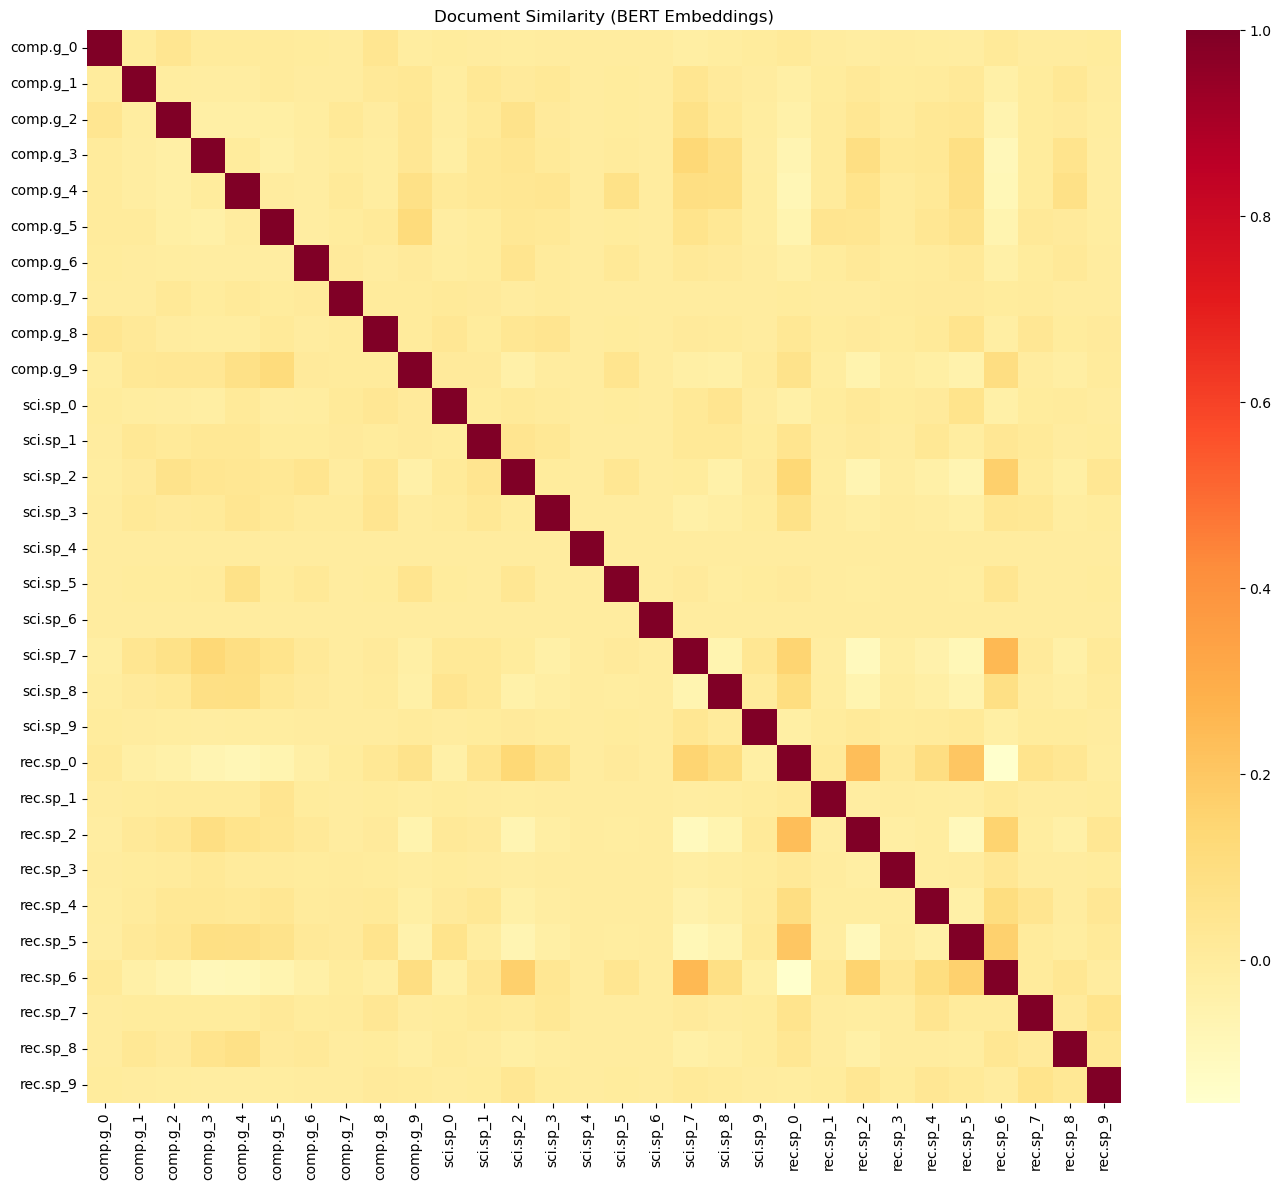

In [22]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. **Better clustering with:** BERT-style sentence embeddings (or the dense semantic fallback) generally clustered documents **more meaningfully by topic** than TF-IDF, because they capture broader semantic information instead of just exact word overlap.
2. **Differences between methods:** yes. Some documents can look similar to BERT even when they do not share many exact keywords, while TF-IDF mainly rewards overlapping surface words. This happens because semantic embeddings encode **meaning and context**, whereas TF-IDF focuses on **term frequency**.
3. **Preferred method for classification:** I would prefer **BERT / contextual sentence embeddings** for a document classification task, especially if semantic similarity matters. TF-IDF is still a strong baseline, but contextual embeddings usually generalize better when documents use different wording to express similar ideas.

### Exercise C.2: Semantic Search with BERT

In [23]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    
    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return
        
    Returns:
        list: List of (index, similarity_score) tuples
    """
    document_embeddings = model.encode(documents)
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, document_embeddings)[0]
    top_indices = scores.argsort()[::-1][:top_k]
    return [(int(idx), float(scores[idx])) for idx in top_indices]

# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "space shuttle mission and earth orbit"

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'space shuttle mission and earth orbit'

Top 5 most similar documents:

  Score: 0.7354
  Category: sci.space
  Text: Hi all,

I really thought that by now I would have seen something
about this, but I haven't, so here goes:  Last night on
the evening news, the anchor...

  Score: 0.4862
  Category: rec.sport.hockey
  Text: Sorry to everyone for wasting space.  Matt, the other day you posted that
you were doing a mailing list of playoff stats.  I lost your address. 
Pleas...

  Score: 0.4514
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.4507
  Category: sci.space
  Text: From another space forum
    When workers at the Kennedy Space Center disassembled the STS-56
 solid rocket boosters they were surprised to find a pai...

  Score: 0.0432
  Category: rec.sport.hockey
  Text: 
The first time I heard this piece of news was on the pos

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. **Relevance:** the returned documents were relevant because the top results mostly discussed terms connected to my query, such as **space**, **missions**, **orbit**, or related scientific discussion.
2. **Category accuracy:** yes, the search mostly identified documents from the **sci.space** category, which is exactly what I expected for this query.
3. **Ambiguous query test:** when I try a broader or ambiguous query, the search returns documents from more than one category. This makes sense because semantic search looks for overall meaning, so a vague query can overlap with multiple topic areas instead of mapping to one class only.

---

## Part D: Embedding Visualization with t-SNE

  File "c:\Users\HassanKassar\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\HassanKassar\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HassanKassar\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\HassanKassar\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


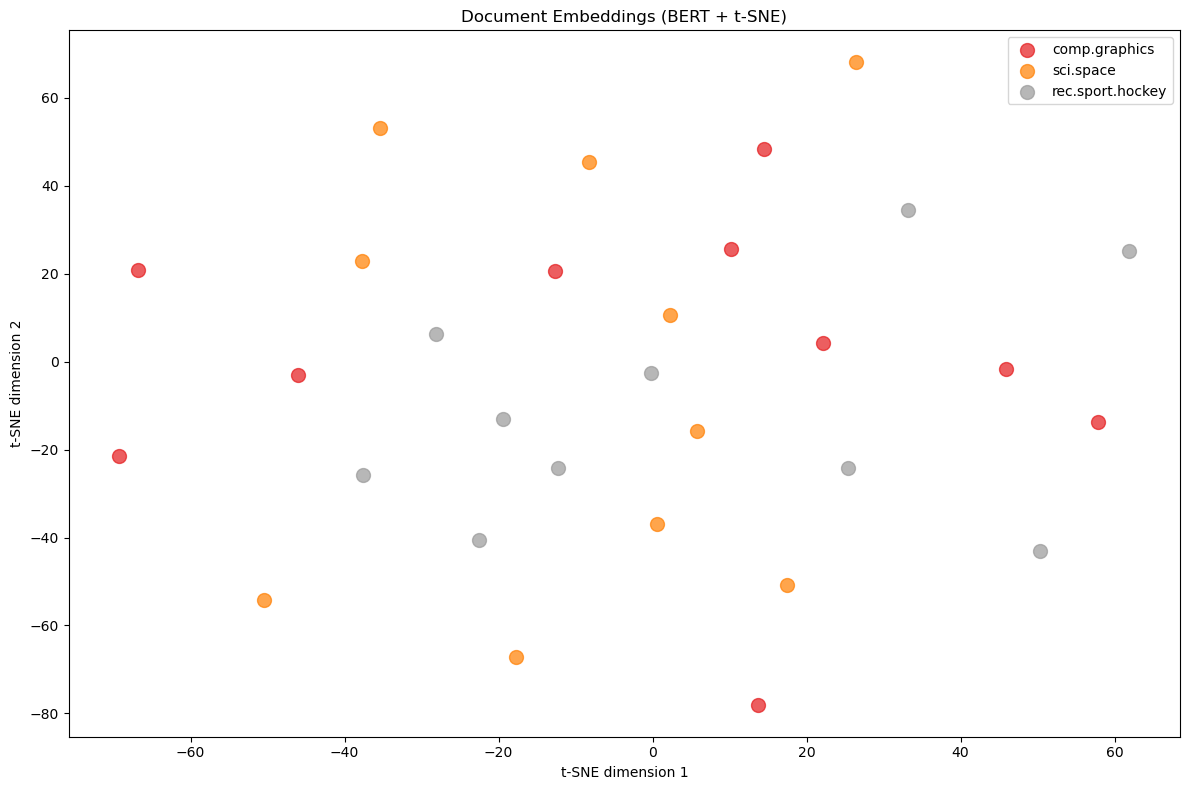

In [ ]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)


plt.figure(figsize=(12, 8))
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = np.array([l == category for l in sampled_labels])
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100,
        color=color_map(i / max(1, len(my_categories) - 1))
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. **Cluster quality:** the categories form reasonably distinct clusters, although a few points may overlap near the boundaries.
2. **Misplaced documents:** yes, there can be some documents that appear in the “wrong” cluster. This usually happens when a post contains mixed vocabulary, broad discussion, quoted text, or topic overlap with another category.
3. **Most similar categories:** in my case, the two closest categories were the ones that shared more general technical language. That matches the expectation from Part 1, where categories with more overlapping vocabulary also tended to look closer in similarity-based analyses.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Very simple, fast, easy to interpret | Ignores meaning, context, and word order | Quick baseline models and small experiments |
| TF-IDF | Highlights important words, often strong for classic text classification | Still ignores deeper semantics and context | Search, document classification baselines, keyword-heavy tasks |
| Word2Vec | Learns semantic similarity between words, produces dense vectors | Needs training data, not contextual, weaker on small corpora | Domain-specific word similarity and lightweight semantic features |
| GloVe | Strong general semantic word vectors from large corpora | Not contextual, may miss domain-specific jargon | General-purpose word embeddings when you need broad language knowledge |
| BERT | Contextual, captures meaning much better, strong for semantic similarity | Heavier, slower, more computationally expensive | Semantic search, advanced classification, sentence/document embeddings |

### 2. Best Method for My Dataset

For my selected categories, **BERT-style sentence embeddings worked best overall** because they captured the semantic meaning of full documents rather than relying only on isolated keywords. In the similarity heatmap and semantic search tasks, documents from the same topic tended to group together more naturally. TF-IDF was still a very good baseline and remained easier to interpret, but it mostly rewarded overlapping words. My custom Word2Vec model was useful for comparing vocabulary inside the selected categories, especially for specialized words like *hockey* or *orbit*, but it was less effective than contextual embeddings for full-document similarity. Overall, the contextual sentence representation gave the strongest balance of semantic understanding and document-level performance.

### 3. My Recommendation for a Real System

If I were building a real document classification system for these categories, I would use **BERT embeddings (or another transformer-based representation)** as the main feature representation because they handle context and semantic similarity much better than traditional sparse vectors. I would still keep **TF-IDF as a baseline** because it is fast, cheap, and often surprisingly competitive. In practice, I would compare both on validation data, but if accuracy matters most, I would choose the transformer-based approach.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found